In [2]:
# Import necessary libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import string
import nltk

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [8]:
import zipfile

with zipfile.ZipFile("archive (1).zip", "r") as zip_ref:
    zip_ref.extractall()

In [10]:
import os

os.listdir()

['.config',
 '.ipynb_checkpoints',
 'combined_data.csv',
 'archive (1).zip',
 'sample_data']

In [12]:
import pandas as pd

df = pd.read_csv("combined_data.csv")

In [13]:
df.head()
df.columns

Index(['label', 'text'], dtype='object')

In [14]:
print(df.shape)

(83448, 2)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   83448 non-null  int64 
 1   text    83448 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [16]:
df.isnull().sum()

,0
label,0
text,0


In [17]:
df['label'].value_counts()

,count
label,
1,43910
0,39538


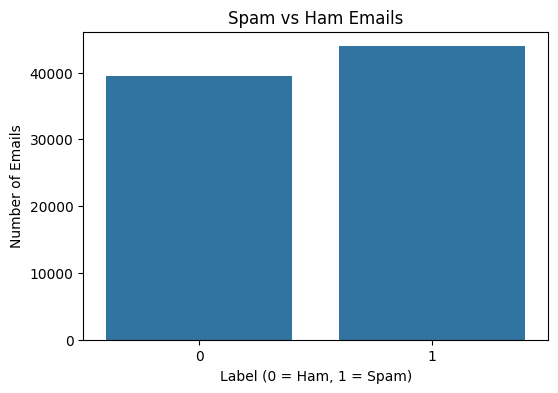

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Emails")
plt.xlabel("Label (0 = Ham, 1 = Spam)")
plt.ylabel("Number of Emails")
plt.show()

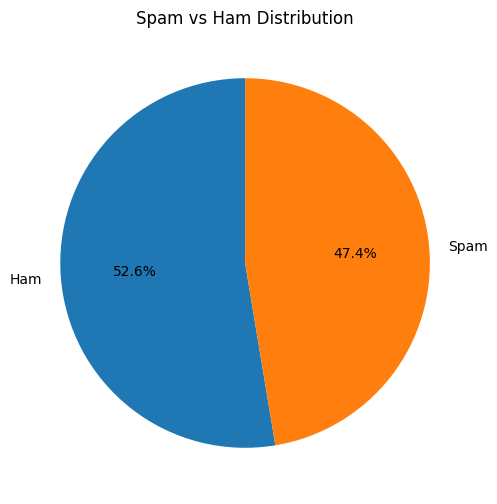

In [19]:
plt.figure(figsize=(6,6))

df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Ham','Spam'],
    startangle=90
)

plt.title("Spam vs Ham Distribution")
plt.ylabel("")
plt.show()

In [20]:
df['email_length'] = df['text'].apply(len)

df.head()

,label,text,email_length
0,1,ounce feather bowl hummingbird opec moment ala...,148
1,1,wulvob get your medircations online qnb ikud v...,808
2,0,computer connection from cnn com wednesday es...,2235
3,1,university degree obtain a prosperous future m...,592
4,0,thanks for all your answers guys i know i shou...,1362


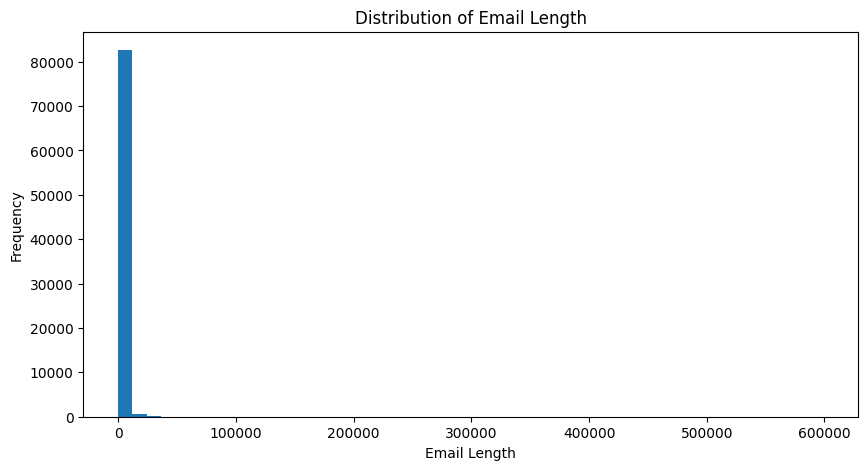

In [21]:
plt.figure(figsize=(10,5))

plt.hist(df['email_length'], bins=50)

plt.title("Distribution of Email Length")
plt.xlabel("Email Length")
plt.ylabel("Frequency")

plt.show()

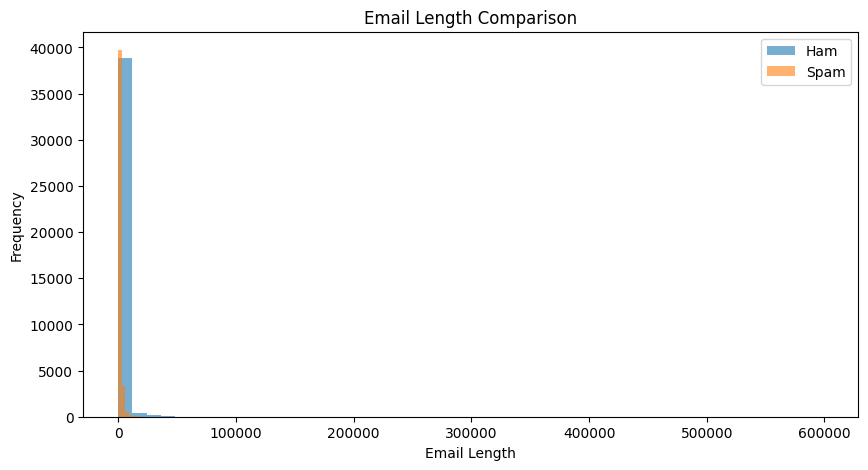

In [22]:
plt.figure(figsize=(10,5))

plt.hist(df[df['label']==0]['email_length'],
         bins=50,
         alpha=0.6,
         label='Ham')

plt.hist(df[df['label']==1]['email_length'],
         bins=50,
         alpha=0.6,
         label='Spam')

plt.legend()

plt.title("Email Length Comparison")
plt.xlabel("Email Length")
plt.ylabel("Frequency")

plt.show()

In [23]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

df.head()

,label,text,email_length,word_count
0,1,ounce feather bowl hummingbird opec moment ala...,148,20
1,1,wulvob get your medircations online qnb ikud v...,808,103
2,0,computer connection from cnn com wednesday es...,2235,337
3,1,university degree obtain a prosperous future m...,592,76
4,0,thanks for all your answers guys i know i shou...,1362,222


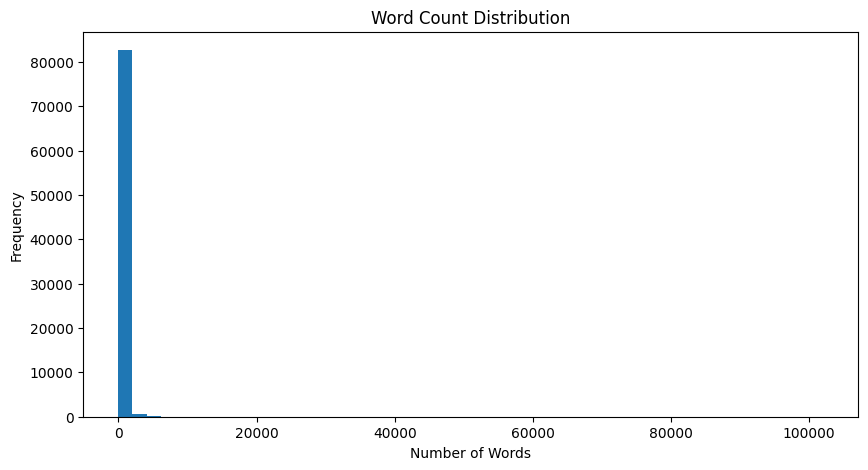

In [24]:
plt.figure(figsize=(10,5))

plt.hist(df['word_count'], bins=50)

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [25]:
df.groupby('label')['email_length'].mean()

,email_length
label,
0,2121.693814
1,1249.887247
